In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_theme()

import warnings
warnings.filterwarnings("ignore")

In [5]:
# import segmentation model
scaler = joblib.load("models/scaler_model.pkl")
kmeans_pca = joblib.load("models/kmeans_pca_model.pkl")
pca = joblib.load("models/pca_model.pkl")

In [6]:
df_purchase = pd.read_csv("data/purchase_data.csv")
df_purchase.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,...,Promotion_3,Promotion_4,Promotion_5,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,200000001,1,0,0,0,0,0,1.59,1.87,2.01,...,0,0,0,0,0,47,1,110866,1,0
1,200000001,11,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0
2,200000001,12,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0
3,200000001,16,0,0,0,0,0,1.52,1.89,1.98,...,0,0,0,0,0,47,1,110866,1,0
4,200000001,18,0,0,0,0,0,1.52,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0


In [7]:
df_purchase.isnull().sum()

ID                   0
Day                  0
Incidence            0
Brand                0
Quantity             0
Last_Inc_Brand       0
Last_Inc_Quantity    0
Price_1              0
Price_2              0
Price_3              0
Price_4              0
Price_5              0
Promotion_1          0
Promotion_2          0
Promotion_3          0
Promotion_4          0
Promotion_5          0
Sex                  0
Marital status       0
Age                  0
Education            0
Income               0
Occupation           0
Settlement size      0
dtype: int64

In [8]:
# standardization
features = df_purchase[['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement size']]
df_purchase_segm_std = scaler.transform(features)


In [9]:
### PCA
df_purchase_segm_pca = pca.transform(df_purchase_segm_std)

In [10]:
### K-means PCA
purchase_segm_kmeans_pca = kmeans_pca.predict(df_purchase_segm_pca)

In [11]:
df_purchase_predictors = df_purchase.copy()

In [12]:
df_purchase_predictors['Segment'] = purchase_segm_kmeans_pca

#### Descriptive analysis of segments ####

In [13]:
### Data Analysis by Customer ###
df_purchase_predictors.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,...,Promotion_4,Promotion_5,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Segment
0,200000001,1,0,0,0,0,0,1.59,1.87,2.01,...,0,0,0,0,47,1,110866,1,0,0
1,200000001,11,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,0,47,1,110866,1,0,0
2,200000001,12,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,0,47,1,110866,1,0,0
3,200000001,16,0,0,0,0,0,1.52,1.89,1.98,...,0,0,0,0,47,1,110866,1,0,0
4,200000001,18,0,0,0,0,0,1.52,1.89,1.99,...,0,0,0,0,47,1,110866,1,0,0


In [14]:
temp1 = df_purchase_predictors[['ID', 'Incidence']].groupby(['ID'], as_index = False).count()
temp1 = temp1.set_index('ID')
temp1 = temp1.rename(columns = {'Incidence': 'N_Visits'})
temp1.head()

,N_Visits
ID,
200000001,101
200000002,87
200000003,97
200000004,85
200000005,111


In [15]:
temp2 = df_purchase_predictors[['ID', 'Incidence']].groupby(['ID'], as_index = False).sum()
temp2 = temp2.set_index('ID')
temp2 = temp2.rename(columns = {'Incidence': 'N_Purchases'})
temp3 = temp1.join(temp2)
temp3.head()

,N_Visits,N_Purchases
ID,,
200000001,101,9
200000002,87,11
200000003,97,10
200000004,85,11
200000005,111,13


In [16]:
temp3['Average_N_Purchases'] = temp3['N_Purchases'] / temp3['N_Visits']
temp3.head()

,N_Visits,N_Purchases,Average_N_Purchases
ID,,,
200000001,101,9,0.089109
200000002,87,11,0.126437
200000003,97,10,0.103093
200000004,85,11,0.129412
200000005,111,13,0.117117


In [17]:
temp4 = df_purchase_predictors[['ID', 'Segment']].groupby(['ID'], as_index = False).mean()
temp4 = temp4.set_index('ID')
df_purchase_descr = temp3.join(temp4)
df_purchase_descr.head()

,N_Visits,N_Purchases,Average_N_Purchases,Segment
ID,,,,
200000001,101,9,0.089109,0.0
200000002,87,11,0.126437,3.0
200000003,97,10,0.103093,0.0
200000004,85,11,0.129412,1.0
200000005,111,13,0.117117,0.0


In [18]:
segm_prop = df_purchase_descr[['N_Purchases', 'Segment']].groupby(['Segment']).count() / df_purchase_descr.shape[0]
segm_prop = segm_prop.rename(columns = {'N_Purchases': 'Segment_Proportion'})
segm_prop.head()

,Segment_Proportion
Segment,
0.0,0.290
1.0,0.362
2.0,0.152
3.0,0.196


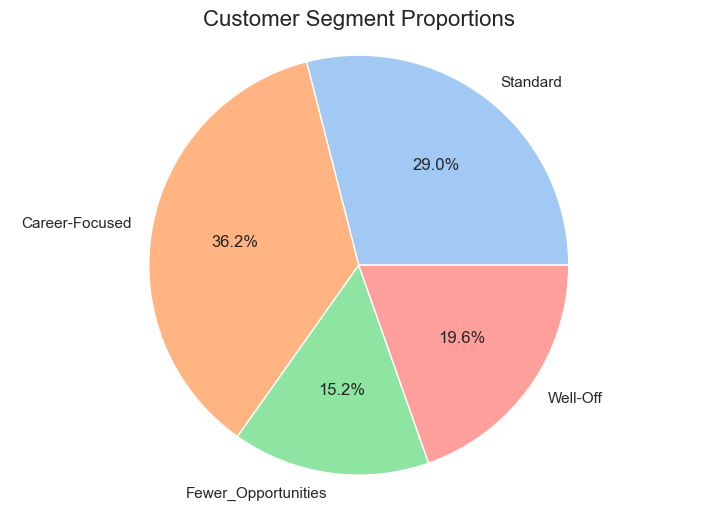

In [19]:
plt.figure(figsize = (9, 6))
plt.pie(segm_prop['Segment_Proportion'],
        labels = ['Standard', 'Career-Focused', 'Fewer_Opportunities', 'Well-Off'],
        autopct = '%1.1f%%',
        colors = sns.color_palette('pastel'))
plt.title('Customer Segment Proportions', fontsize = 16)
plt.axis('equal')
plt.show()

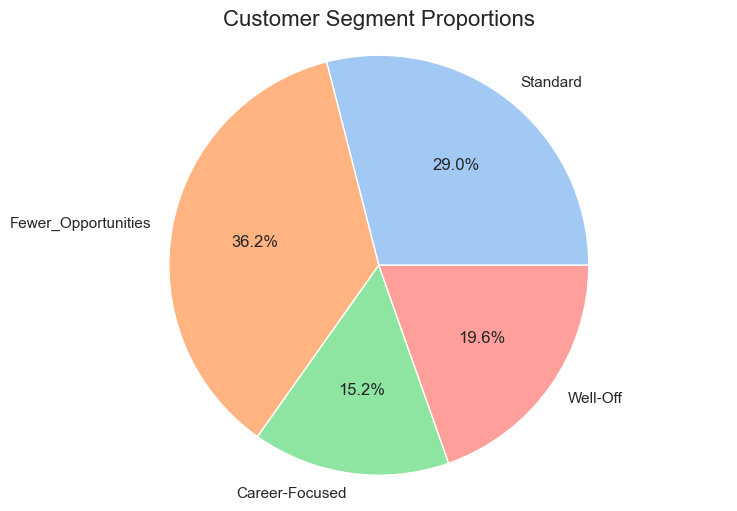

In [20]:
plt.figure(figsize = (9, 6))
plt.pie(segm_prop['Segment_Proportion'],
        labels = ['Standard', 'Fewer_Opportunities', 'Career-Focused', 'Well-Off'],
        autopct = '%1.1f%%',
        colors = sns.color_palette('pastel'))
plt.title('Customer Segment Proportions', fontsize = 16)
plt.axis('equal')
plt.show()

In [21]:
segments_mean = df_purchase_descr.groupby(['Segment']).mean()
segments_mean

,N_Visits,N_Purchases,Average_N_Purchases
Segment,,,
0.0,120.489655,34.965517,0.258081
1.0,114.303867,22.823204,0.201760
2.0,118.828947,27.171053,0.228956
3.0,117.367347,34.408163,0.282601


In [22]:
segments_std = df_purchase_descr.groupby(['Segment']).std()

Text(0.5, 1.0, 'Average Number of Store Visits by segment')

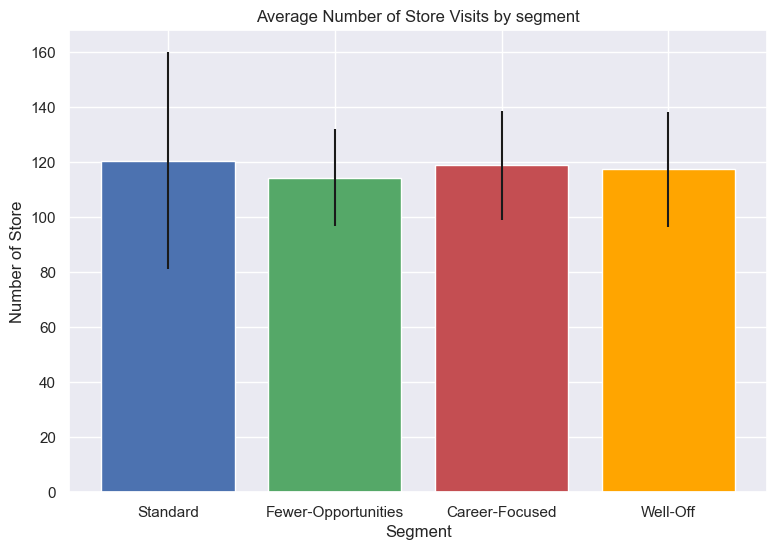

In [23]:
plt.figure(figsize = (9,6))
plt.bar(x = (0, 1, 2, 3),
        tick_label = ('Standard', 'Fewer-Opportunities', 'Career-Focused', 'Well-Off'),
        height = segments_mean['N_Visits'],
        yerr = segments_std['N_Visits'],
        color = ('b', 'g', 'r', 'orange'))
plt.xlabel('Segment')
plt.ylabel('Number of Store')
plt.title('Average Number of Store Visits by segment')


Text(0.5, 1.0, 'Number of Purchased by Segment')

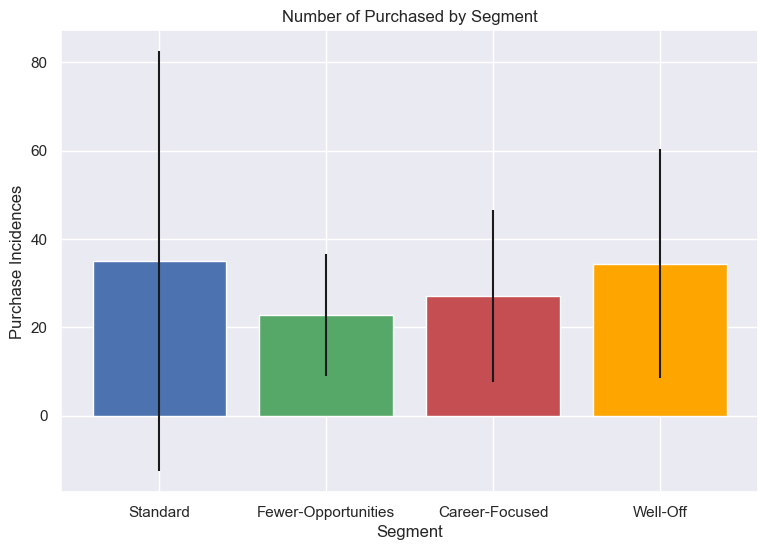

In [24]:
plt.figure(figsize = (9,6))
plt.bar(x = (0, 1, 2, 3),
        tick_label = ('Standard', 'Fewer-Opportunities', 'Career-Focused', 'Well-Off'),
        height = segments_mean['N_Purchases'],
        yerr = segments_std['N_Purchases'],
        color = ('b', 'g', 'r', 'orange'))
plt.xlabel('Segment')
plt.ylabel('Purchase Incidences')
plt.title('Number of Purchased by Segment')


Text(0.5, 1.0, 'Average Number of Purchases by Segment')

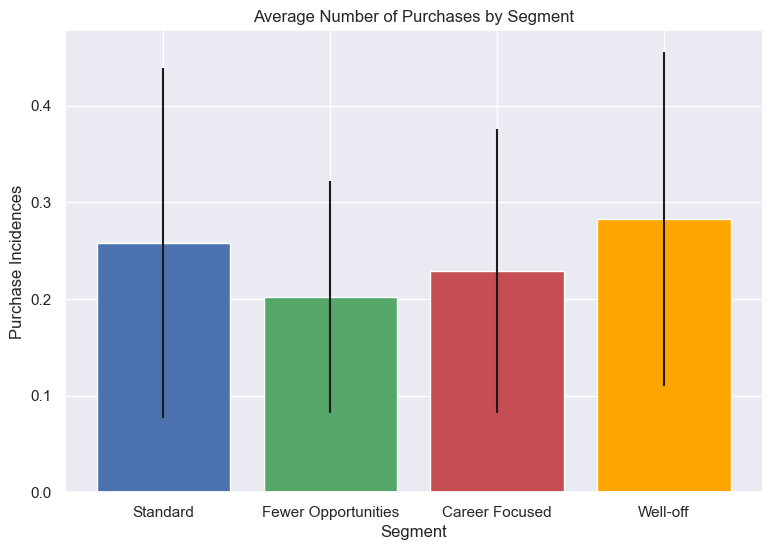

In [25]:
plt.figure(figsize = (9, 6))
plt.bar(x = (0, 1, 2, 3),
        tick_label = ('Standard','Fewer Opportunities', 'Career Focused','Well-off'),
        height = segments_mean['Average_N_Purchases'],
        yerr = segments_std['Average_N_Purchases'],
        color = ('b', 'g', 'r', 'orange'))
plt.xlabel('Segment')
plt.ylabel('Purchase Incidences')
plt.title('Average Number of Purchases by Segment')

In [26]:
### Brand Choice

df_purchase_incidence = df_purchase_predictors[df_purchase_predictors['Incidence'] == 1]

In [27]:
brand_dummies = pd.get_dummies(df_purchase_incidence['Brand'], prefix = 'Brand', prefix_sep = '_')
brand_dummies['Segment'], brand_dummies['ID'] = df_purchase_incidence['Segment'], df_purchase_incidence['ID']
brand_dummies

,Brand_1,Brand_2,Brand_3,Brand_4,Brand_5,Segment,ID
6,False,True,False,False,False,0,200000001
11,False,False,False,False,True,0,200000001
19,True,False,False,False,False,0,200000001
24,False,False,False,True,False,0,200000001
29,False,True,False,False,False,0,200000001
...,...,...,...,...,...,...,...
58621,False,True,False,False,False,0,200000500
58648,True,False,False,False,False,0,200000500
58674,False,True,False,False,False,0,200000500
58687,False,True,False,False,False,0,200000500


In [28]:
temp = brand_dummies.groupby(['ID'], as_index = True).mean()

In [29]:
mean_brand_choice = temp.groupby(['Segment'], as_index = True).mean()

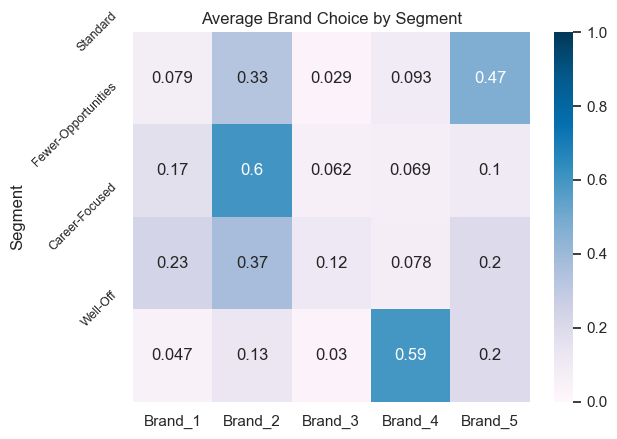

In [30]:
sns.heatmap(mean_brand_choice,
            vmin = 0,
            vmax = 1,
            cmap = 'PuBu',
            annot = True)
plt.yticks([0, 1, 2, 3], ['Standard', 'Fewer-Opportunities', 'Career-Focused', 'Well-Off'], rotation = 45, fontsize = 9)
plt.title('Average Brand Choice by Segment')
plt.show()

In [31]:
### Revenue
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 1]
temp.loc[:, 'Revenue Brand 1'] = temp['Price_1'] * temp['Quantity']
segments_brand_revenue = pd.DataFrame()
segments_brand_revenue[['Segment', 'Revenue Brand 1']] = temp[['Segment', 'Revenue Brand 1']].groupby(['Segment'], as_index = False).sum()
segments_brand_revenue


,Segment,Revenue Brand 1
0,0,912.12
1,1,2807.51
2,2,1869.77
3,3,716.25


In [32]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 2]
temp.loc[:, 'Revenue Brand 2'] = temp['Price_2'] * temp['Quantity']
segments_brand_revenue[['Segment', 'Revenue Brand 2']] = temp[['Segment', 'Revenue Brand 2']].groupby(['Segment'], as_index = False).sum()


In [33]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 3]
temp.loc[:, 'Revenue Brand 3'] = temp['Price_3'] * temp['Quantity']
segments_brand_revenue[['Segment', 'Revenue Brand 3']] = temp[['Segment', 'Revenue Brand 3']].groupby(['Segment'], as_index = False).sum()


In [34]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 4]
temp.loc[:, 'Revenue Brand 4'] = temp['Price_4'] * temp['Quantity']
segments_brand_revenue[['Segment', 'Revenue Brand 4']] = temp[['Segment', 'Revenue Brand 4']].groupby(['Segment'], as_index = False).sum()


In [35]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 5]
temp.loc[:, 'Revenue Brand 5'] = temp['Price_5'] * temp['Quantity']
segments_brand_revenue[['Segment', 'Revenue Brand 5']] = temp[['Segment', 'Revenue Brand 5']].groupby(['Segment'], as_index = False).sum()


In [36]:
segments_brand_revenue['Total Revenue'] = (segments_brand_revenue['Revenue Brand 1']+
                                           segments_brand_revenue['Revenue Brand 2']+
                                           segments_brand_revenue['Revenue Brand 3']+
                                           segments_brand_revenue['Revenue Brand 4']+
                                           segments_brand_revenue['Revenue Brand 5'])
segments_brand_revenue

,Segment,Revenue Brand 1,Revenue Brand 2,Revenue Brand 3,Revenue Brand 4,Revenue Brand 5,Total Revenue
0,0,912.12,5222.99,603.79,2268.95,17838.72,26846.57
1,1,2807.51,11742.86,2388.88,1910.89,2638.52,21488.66
2,2,1869.77,3382.47,2303.31,1165.16,3638.75,12359.46
3,3,716.25,1419.99,725.54,13695.10,5505.01,22061.89


In [37]:
print(segm_prop.columns)

Index(['Segment_Proportion'], dtype='object')


In [38]:
segments_brand_revenue['Segment Proportions'] = segm_prop['Segment_Proportion']  # Changed this
segments_brand_revenue['Segment'] = segments_brand_revenue['Segment'].map({0: 'Standard',
    1:'Fewer-Opportunities', 2: 'Career-Focused', 3:'Well-Off'})

In [39]:
segments_brand_revenue = segments_brand_revenue.set_index(['Segment'])
segments_brand_revenue

,Revenue Brand 1,Revenue Brand 2,Revenue Brand 3,Revenue Brand 4,Revenue Brand 5,Total Revenue,Segment Proportions
Segment,,,,,,,
Standard,912.12,5222.99,603.79,2268.95,17838.72,26846.57,0.290
Fewer-Opportunities,2807.51,11742.86,2388.88,1910.89,2638.52,21488.66,0.362
Career-Focused,1869.77,3382.47,2303.31,1165.16,3638.75,12359.46,0.152
Well-Off,716.25,1419.99,725.54,13695.10,5505.01,22061.89,0.196
